In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/cleaned_telco.csv")
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [3]:
y = df["Churn Value"]
X = df.drop(columns = ["Churn Value"])

In [4]:
leakage_cols = ["Churn Label", "Churn Score","CLTV","Churn Reason"]

X = X.drop(columns=leakage_cols)

In [6]:
def tenure_group(X):
    if X <= 12:
        return "Early"
    elif X <= 24:
        return "Mid"
    else:
        return "Long"

X["Tenure_Group"] = X["Tenure Months"].apply(tenure_group)

X["Charge_to_Tenure"] = X["Monthly Charges"] / (X["Tenure Months"] + 1)

service_cols = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]

for col in service_cols:
    X[col] = X[col].map({"Yes":1,"No":0})

X["Service_Count"] = X[service_cols].sum(axis=1)

X["Gender"] = X["Gender"].str.strip().map({"Male":1,"Female":0})

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [19]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

In [20]:
numeric_transformer =Pipeline(
    steps=[("scaler", StandardScaler())]
)

categorical_transformer = Pipeline(
    steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [21]:
log_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

log_pipeline.fit(X_train, y_train)

log_pred = log_pipeline.predict(X_test)
log_prob = log_pipeline.predict_proba(X_test)[:,1]

In [23]:
log_metrics = {
    "Accuracy":accuracy_score(y_test, log_pred),
    "Precision":precision_score(y_test, log_pred),
    "Recall":recall_score(y_test, log_pred),
    "F1": f1_score(y_test, log_pred),
    "ROC_AUC":roc_auc_score(y_test, log_prob)
}

log_metrics

{'Accuracy': 0.8045486851457001,
 'Precision': 0.6468842729970327,
 'Recall': 0.5828877005347594,
 'F1': 0.6132208157524613,
 'ROC_AUC': 0.844610474657169}

In [24]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:,1]

In [25]:
rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred),
    "ROC_AUC": roc_auc_score(y_test, rf_prob)
}

rf_metrics

{'Accuracy': 0.7867803837953091,
 'Precision': 0.6201298701298701,
 'Recall': 0.5106951871657754,
 'F1': 0.5601173020527859,
 'ROC_AUC': 0.8279568361710609}

In [28]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(eval_metric="logloss", random_state=42))
    ]
)

xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:,1]

In [29]:
xgb_metrics = {
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1": f1_score(y_test, xgb_pred),
    "ROC_AUC": roc_auc_score(y_test, xgb_prob)
}

xgb_metrics

{'Accuracy': 0.7725657427149965,
 'Precision': 0.574585635359116,
 'Recall': 0.5561497326203209,
 'F1': 0.5652173913043478,
 'ROC_AUC': 0.825160091318055}

In [30]:
comparison = pd.DataFrame(
    [log_metrics, rf_metrics, xgb_metrics],
    index=["Logistic Regression", "Random Forest", "XGBoost"]
)

comparison

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.804549,0.646884,0.582888,0.613221,0.844610
Random Forest,0.786780,0.620130,0.510695,0.560117,0.827957
XGBoost,0.772566,0.574586,0.556150,0.565217,0.825160


In [31]:
param_grid = {
    "model__n_estimators":[100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate":[0.01, 0.1, 0.2]
}

search = RandomizedSearchCV(
    xgb_pipeline,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_iter=10,
    n_jobs=-1
)

search.fit(X_train, y_train)

search.best_params_

{'model__n_estimators': 100,
 'model__max_depth': 3,
 'model__learning_rate': 0.1}

In [32]:
final_model = search.best_estimator_

final_pred = final_model.predict(X_test)
final_prob = final_model.predict_proba(X_test)[:,1]

In [34]:
model = final_model.named_steps["model"]

feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

importances = model.feature_importances_

feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance",ascending=False)

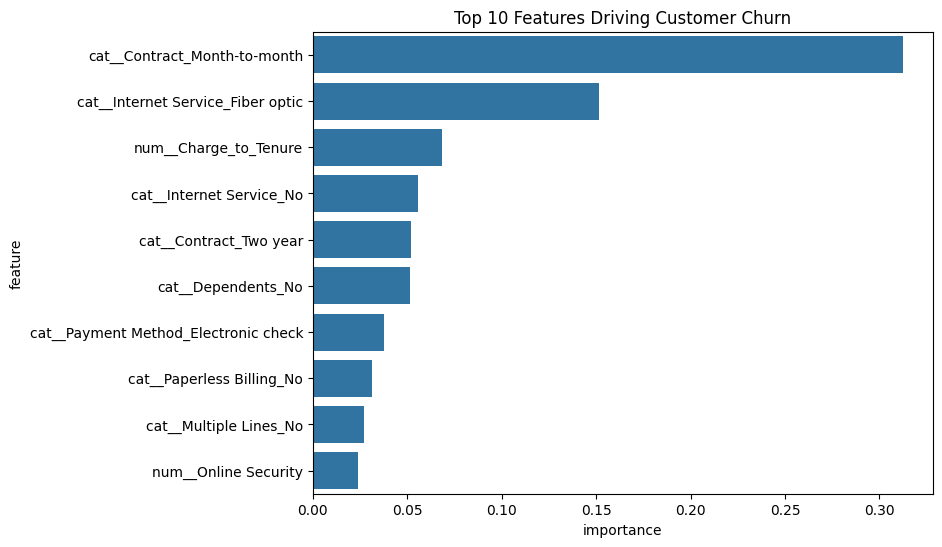

In [35]:
top_features = feat_df.head(10)

plt.figure(figsize=(8,6))
sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 10 Features Driving Customer Churn")
plt.show()

## Business Insight and Final Report.

The detailed business insights and interpretation of the churn drivers are documents in the report.

Please refer to:

**reports/customer_churn_analysis_report.pdf**

This report contains:
- Key churn drivers
- Business interpretation of model results
- Strrategic recommendations to reduce customer churn